# DFT of sinusoids with different amounts of data
## Look at performance gains of zero padding if no extra data exists


In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Course utilities (do not modify this cell)        
import sys
import os
base_path = os.path.expanduser("~/Documents/GitHub/Signals_and_Systems")
sys.path.insert(0, base_path)
sys.path.insert(0, os.path.join(base_path, "courseutils"))

import basic_material as bm
print("Basic Material version:", bm.__version__)
bm.setup_environment()


Basic Material version: 16.002-0.1


In [3]:
colors = bm.get_colors()
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText

from scipy.signal import chirp, spectrogram, windows
from scipy.fftpack import fft, ifft, fftfreq, fftshift, ifftshift
from scipy.io.wavfile import write 


In [4]:
Fs = 1000 #                    % Sampling frequency
T = 1/Fs #                     % Sampling period
L = 2048 #                     % Length of signal

# full set of data
n = int(2**np.ceil(np.log2(L))) #
f = np.linspace(0,1/2-1/n,n)*Fs #   % freq vector 

# a shorter chunk of data to use
na = int(L/4)                      
fa = np.linspace(0,1/2-1/na,na)*Fs #   % freq vector 

In [5]:
#For algorithm performance purposes, fft allows you to pad the input with trailing zeros. 
#In this case, pad each row of X with zeros so that the length of each row is the next higher 
#power of 2 from the current length. Define the new length using the nextpow2 function.
t = np.arange(L)*T #                Time vector
f_sig1 = 20 #hz
f_sig2 = 21 #hz
rng = np.random.default_rng(seed=32)

x1 = np.cos(2*np.pi*f_sig1*t) + np.cos(2*np.pi*f_sig2*t + .1*np.pi) + np.random.rand(1,L)/2
x1 = x1.flatten()
xa = x1[0:na]
x2 = np.append(xa,0*x1[na-1:-1])

In [6]:
# Compute FFT
Y1 = fft(x1)
Ya = fft(xa)
Y2 = fft(x2)
Y1_plot = 1.0/n * fftshift(Y1)
Ya_plot = 1.0/na * fftshift(Ya)
Y2_plot = 1.0/n * fftshift(Y2)

xf = fftfreq(n, 1/Fs)
xf_plot = fftshift(xf)
xfa = fftfreq(na, 1/Fs)
xfa_plot = fftshift(xfa)

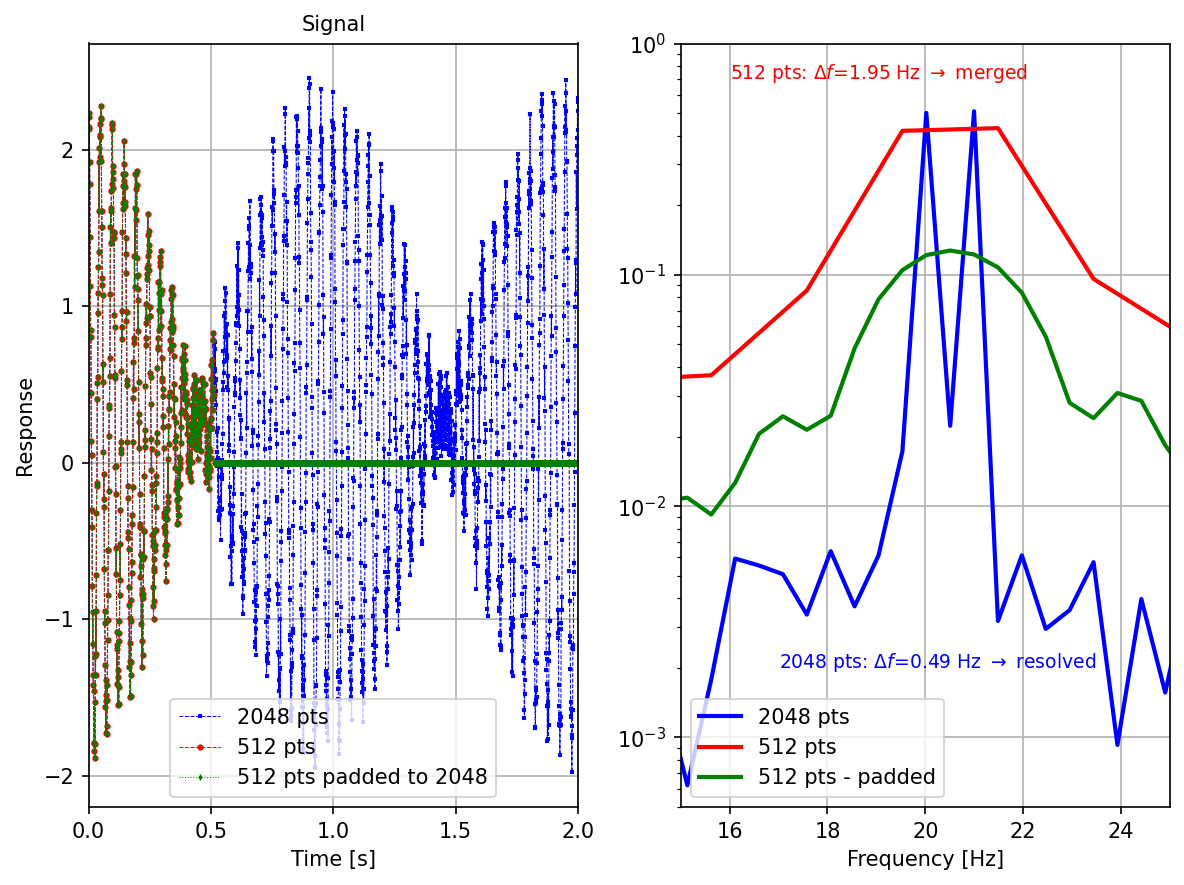

In [7]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,6), dpi=150)
ax1.plot(t, x1,'bs--',label=f'{L:.0f} pts',lw=0.5,ms=1)
ax1.plot(t[0:na], xa,'ro--',label=f'{L/4:.0f} pts',lw=0.5,ms=2)
ax1.plot(t, x2,'gd:',label=f'{L/4:.0f} pts padded to {L:.0f}',lw=0.5,ms=1)
ax1.set_ylabel('Response')
ax1.set_xlabel('Time [s]')
ax1.set_title('Signal')
ax1.legend()
ax1.set_xlim([0, 2])

ax2.semilogy(xf_plot, np.abs(Y1_plot),'b-',label=f'{L:.0f} pts')
ax2.semilogy(xfa_plot, np.abs(Ya_plot),'r-',label=f'{L/4:.0f} pts')
ax2.semilogy(xf_plot, np.abs(Y2_plot),'g-',label=f'{L/4:.0f} pts - padded')
ax2.set_xlim([15, 25])
ax2.set_ylim([5e-4, 1])
ax2.legend(loc=3)
ax2.set_xlabel('Frequency [Hz]')

# --- annotations: resolution comparison ---
df_long  = Fs / n     # long record (blue) bin spacing  -> ~0.49 Hz
df_short = Fs / na    # short record (red/green)        -> ~1.95 Hz

# blue: point to the notch between the two resolved peaks (~20.5 Hz)
ax2.text(17,.002,f'{n} pts: $\\Delta f$={df_long:.2f} Hz $\\rightarrow$ resolved',color='blue', fontsize=9)

# red: point to the merged flat top (~20.5 Hz, near the peak level)
ax2.text(16, .7, f'{na} pts: $\\Delta f$={df_short:.2f} Hz $\\rightarrow$ merged',
         color='red', fontsize=9)

fig.savefig('./figs/T8_ex9a_1.pdf', dpi=300)
plt.show()